In [ ]:
import re
import json
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import log_loss

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [22]:
BASE_PATH = '/kaggle/input/competitions/llm-classification-finetuning'

train = pd.read_csv(f'{BASE_PATH}/train.csv')
test  = pd.read_csv(f'{BASE_PATH}/test.csv')
sub   = pd.read_csv(f'{BASE_PATH}/sample_submission.csv')

print(f'Train: {train.shape} | Test: {test.shape}')

Train: (57477, 9) | Test: (3, 4)


In [23]:
def extract_last_turn(text):
    try:
        parsed = json.loads(text)
        return parsed[-1] if parsed else text
    except:
        try:
            cleaned = re.sub(r'\\(?!["\\/bfnrt]|u[0-9a-fA-F]{4})', r'\\\\', text)
            parsed = json.loads(cleaned)
            return parsed[-1] if parsed else text
        except:
            return text

for df in [train, test]:
    df['prompt_clean']     = df['prompt'].apply(extract_last_turn)
    df['response_a_clean'] = df['response_a'].apply(extract_last_turn)
    df['response_b_clean'] = df['response_b'].apply(extract_last_turn)
    for col in ['prompt_clean', 'response_a_clean', 'response_b_clean']:
        df[col] = df[col].fillna('')

print("Preprocesamiento completado")

Preprocesamiento completado


In [24]:
df.head()

,id,prompt,response_a,response_b,prompt_clean,response_a_clean,response_b_clean
0,136060,"[""I have three oranges today, I ate an orange ...","[""You have two oranges today.""]","[""You still have three oranges. Eating an oran...","I have three oranges today, I ate an orange ye...",You have two oranges today.,You still have three oranges. Eating an orange...
1,211333,"[""You are a mediator in a heated political deb...","[""Thank you for sharing the details of the sit...","[""Mr Reddy and Ms Blue both have valid points ...",You are a mediator in a heated political debat...,Thank you for sharing the details of the situa...,Mr Reddy and Ms Blue both have valid points in...
2,1233961,"[""How to initialize the classification head wh...","[""When you want to initialize the classificati...","[""To initialize the classification head when p...",I want to do full finetuning,If you want to do full finetuning of the pre-t...,"If you want to perform full finetuning, where ..."


In [25]:
#Markdown bias
def count_markdown_features(text):
    headers    = len(re.findall(r'^#{1,6}\s', text, re.MULTILINE))
    bullets    = len(re.findall(r'^\s*[-*•]\s', text, re.MULTILINE))
    bold       = len(re.findall(r'\*\*.*?\*\*', text))
    code_inline = len(re.findall(r'`[^`]+`', text))
    code_block = len(re.findall(r'```[\s\S]*?```', text))
    numbered   = len(re.findall(r'^\s*\d+\.\s', text, re.MULTILINE))
    return headers, bullets, bold, code_inline, code_block, numbered

In [26]:
#Readability (Flesch-Kincaid)
def avg_word_length(text):
    words = text.split()
    if not words: return 0
    return np.mean([len(w) for w in words])

def avg_sentence_length(text):
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    if not sentences: return 0
    return np.mean([len(s.split()) for s in sentences])

In [27]:
#Directness score
def starts_directly(text, prompt):
    """¿La respuesta empieza respondiendo o con filler?"""
    fillers = ['certainly', 'of course', 'sure', 'great question',
               'absolutely', 'i understand', 'thank you']
    first_words = text.lower()[:50]
    return int(not any(f in first_words for f in fillers))

In [28]:
#Feature engineering completo

def build_bias_features(df):
    features = {}
    
    for side in ['a', 'b']:
        col = f'response_{side}_clean'
        
        # Markdown
        md = df[col].apply(lambda t: count_markdown_features(str(t)))
        features[f'headers_{side}']     = md.apply(lambda x: x[0])
        features[f'bullets_{side}']     = md.apply(lambda x: x[1])
        features[f'bold_{side}']        = md.apply(lambda x: x[2])
        features[f'code_inline_{side}'] = md.apply(lambda x: x[3])
        features[f'code_block_{side}']  = md.apply(lambda x: x[4])
        features[f'numbered_{side}']    = md.apply(lambda x: x[5])
        
        # Readability
        features[f'avg_word_len_{side}']  = df[col].apply(lambda t: avg_word_length(str(t)))
        features[f'avg_sent_len_{side}']  = df[col].apply(lambda t: avg_sentence_length(str(t)))
        
        # Longitud
        features[f'len_{side}']       = df[col].str.len()
        features[f'word_count_{side}'] = df[col].apply(lambda t: len(str(t).split()))
        
        # Directness
        features[f'direct_{side}'] = df.apply(
            lambda r: starts_directly(str(r[col]), str(r['prompt_clean'])), axis=1
        )
    
    # Features diferenciales A vs B (las más poderosas)
    for feat in ['headers', 'bullets', 'bold', 'code_block', 
                 'avg_word_len', 'avg_sent_len', 'len', 'word_count']:
        features[f'{feat}_diff'] = features[f'{feat}_a'] - features[f'{feat}_b']
        features[f'{feat}_ratio'] = (
            features[f'{feat}_a'] / (features[f'{feat}_b'] + 1)
        )
    
    return pd.DataFrame(features)

In [29]:
print("Generando features...")
X_train_bias = build_bias_features(train)
X_test_bias  = build_bias_features(test)

print(f"Shape train: {X_train_bias.shape}")
print(f"Shape test:  {X_test_bias.shape}")
print(f"\nNulos: {X_train_bias.isna().sum().sum()}")
print(X_train_bias.head(2))

Generando features...
Shape train: (57477, 38)
Shape test:  (3, 38)

Nulos: 0
   headers_a  bullets_a  bold_a  code_inline_a  code_block_a  numbered_a  \
0          0          0       2              0             0           0   
1          0          0       0              0             0           0   

   avg_word_len_a  avg_sent_len_a  len_a  word_count_a  ...  code_block_diff  \
0        4.918919       16.375000   1536           259  ...                0   
1        4.739362       31.333333   1080           188  ...                0   

   code_block_ratio  avg_word_len_diff  avg_word_len_ratio  avg_sent_len_diff  \
0               0.0           0.578010            0.920989           1.708333   
1               0.0          -0.343972            0.779073           9.000000   

   avg_sent_len_ratio  len_diff  len_ratio  word_count_diff  word_count_ratio  
0            1.045213      1067   3.268085              171          2.910112  
1            1.342857       276   1.341615      

In [30]:
def get_winner(row):
    if row['winner_model_a'] == 1: return 0
    if row['winner_model_b'] == 1: return 1
    return 2

train['label'] = train.apply(get_winner, axis=1)
y = train['label'].values
print(f"Clases: {pd.Series(y).value_counts().to_dict()}")

Clases: {0: 20064, 1: 19652, 2: 17761}


In [32]:
groups = train['prompt']

gkf       = GroupKFold(n_splits=5)
oof_preds = np.zeros((len(train), 3))

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,          # reducir de 6 a 4
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    early_stopping_rounds=30,  # detener si no mejora en 30 rondas
    random_state=42,
    n_jobs=-1
)

oof_preds = np.zeros((len(train), 3))

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train_bias, y, groups)):
    X_tr, X_val = X_train_bias.iloc[train_idx], X_train_bias.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=50
    )

    proba = model.predict_proba(X_val)
    # Normalizar para que sumen exactamente 1
    proba = proba / proba.sum(axis=1, keepdims=True)
    
    oof_preds[val_idx] = proba
    fold_loss = log_loss(y_val, proba)
    print(f"Fold {fold+1} — Best iter: {model.best_iteration} | Log Loss: {fold_loss:.4f}")

overall_loss = log_loss(y, oof_preds)
print(f"\nOOF Log Loss Total: {overall_loss:.4f}")
    

[0]	validation_0-mlogloss:1.09369
[50]	validation_0-mlogloss:1.05269
[100]	validation_0-mlogloss:1.05043
[150]	validation_0-mlogloss:1.05014
[177]	validation_0-mlogloss:1.05021
Fold 1 — Best iter: 147 | Log Loss: 1.0501
[0]	validation_0-mlogloss:1.09448
[50]	validation_0-mlogloss:1.05148
[100]	validation_0-mlogloss:1.04876
[150]	validation_0-mlogloss:1.04823
[178]	validation_0-mlogloss:1.04822
Fold 2 — Best iter: 148 | Log Loss: 1.0482
[0]	validation_0-mlogloss:1.09474
[50]	validation_0-mlogloss:1.05263
[100]	validation_0-mlogloss:1.04936
[150]	validation_0-mlogloss:1.04866
[200]	validation_0-mlogloss:1.04837
[250]	validation_0-mlogloss:1.04831
[263]	validation_0-mlogloss:1.04834
Fold 3 — Best iter: 233 | Log Loss: 1.0482
[0]	validation_0-mlogloss:1.09313
[50]	validation_0-mlogloss:1.05083
[100]	validation_0-mlogloss:1.04780
[150]	validation_0-mlogloss:1.04697
[200]	validation_0-mlogloss:1.04673
[250]	validation_0-mlogloss:1.04665
[267]	validation_0-mlogloss:1.04670
Fold 4 — Best iter:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


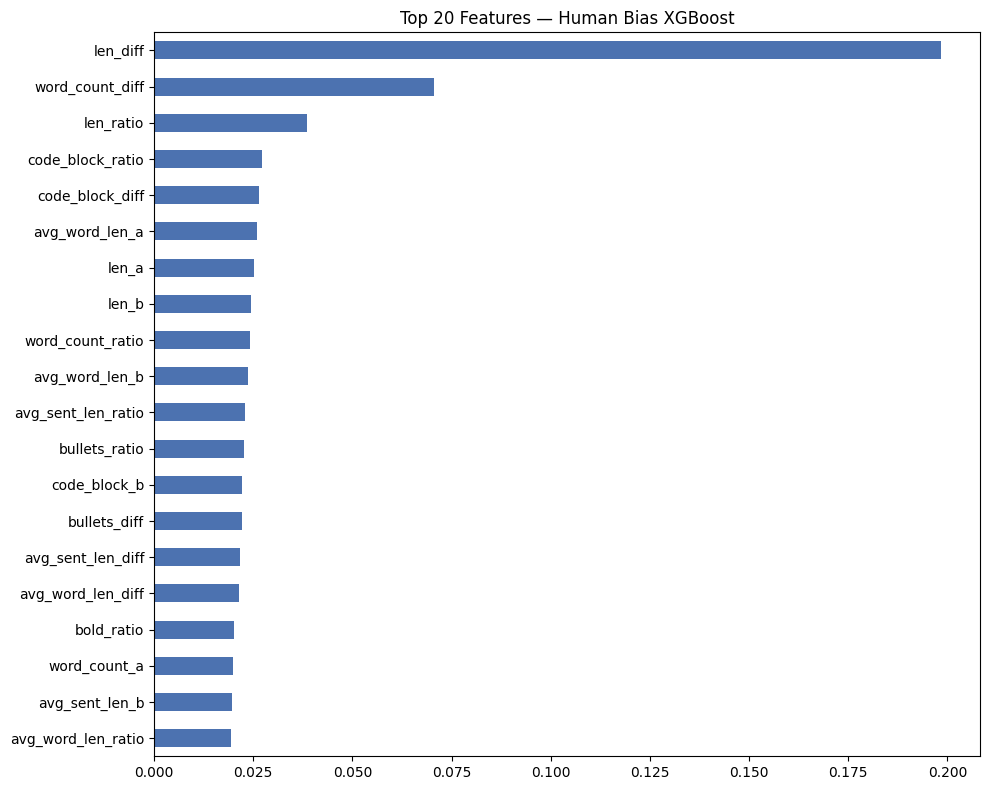

len_diff            0.198317
word_count_diff     0.070674
len_ratio           0.038652
code_block_ratio    0.027271
code_block_diff     0.026440
avg_word_len_a      0.026023
len_a               0.025249
len_b               0.024375
word_count_ratio    0.024095
avg_word_len_b      0.023754
dtype: float32


In [37]:
feat_imp = pd.Series(
    model.feature_importances_,
    index=X_train_bias.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 20 Features — Human Bias XGBoost')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

In [39]:
# Entrenar modelo final sobre todo el train
# Usar best_iteration promedio de los folds
best_iter = int(np.mean([147, 148, 233, 237, 227]))
print(f"Best iteration promedio: {best_iter}")

# Crear modelo sin early stopping y con best_iter
final_model = XGBClassifier(
    n_estimators=best_iter,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_bias, y, verbose=False)
test_preds = final_model.predict_proba(X_test_bias)
test_preds = test_preds / test_preds.sum(axis=1, keepdims=True)

sub['winner_model_a'] = test_preds[:, 0]
sub['winner_model_b'] = test_preds[:, 1]
sub['winner_tie']     = test_preds[:, 2]

sub.to_csv('submission.csv', index=False)
print("Submission guardada")
print(sub)

Best iteration promedio: 198
Submission guardada
        id  winner_model_a  winner_model_b  winner_tie
0   136060        0.304702        0.299978    0.395320
1   211333        0.580957        0.209596    0.209448
2  1233961        0.326329        0.415133    0.258538
